# EDA draft — 5 basic charts

Draft required by the Member 5 task brief (docs/tasks/viz-integration.md): salary distribution, top skills, locations, seniority, posting timeline. Runs on the real frozen data (milestone 2) instead of the sample fixtures. Full version: `eda_full.ipynb`.

**Required data:** `data/processed/jobs_clean.parquet` and `data/processed/skill_matrix.parquet` (download from Drive, or run `python scripts/run_pipeline.py skills`). Hashes must match `docs/MANIFEST.json`.

The notebook only shows aggregate numbers and **never** prints raw job-description text (ToS commitment, `docs/DECISIONS.md` 29/09).

In [1]:
import sys
from pathlib import Path

# Works whether the notebook is opened from the repo root or from notebooks/
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.viz.eda import FIGURES, group_label, load_data, save_figure, salary_tertiles, skill_share

# load_data() checks the SHA-256 of jobs_clean + skill_matrix against docs/MANIFEST.json and stops on mismatch
jobs, skills = load_data()
print(f"{len(jobs)} jobs, {skills.shape[1]} skills — hashes match docs/MANIFEST.json")

688 jobs, 100 skills — hashes match docs/MANIFEST.json


## 1. Salary distribution (jobs with a disclosed salary)

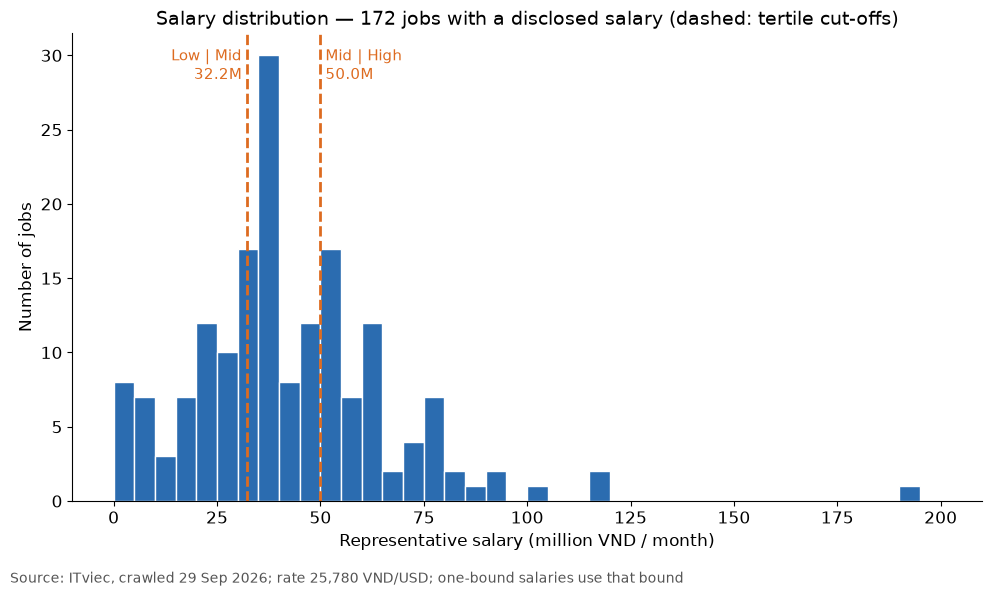

In [2]:
fig = FIGURES["salary_distribution"](jobs, skills)

## 2. Top skills

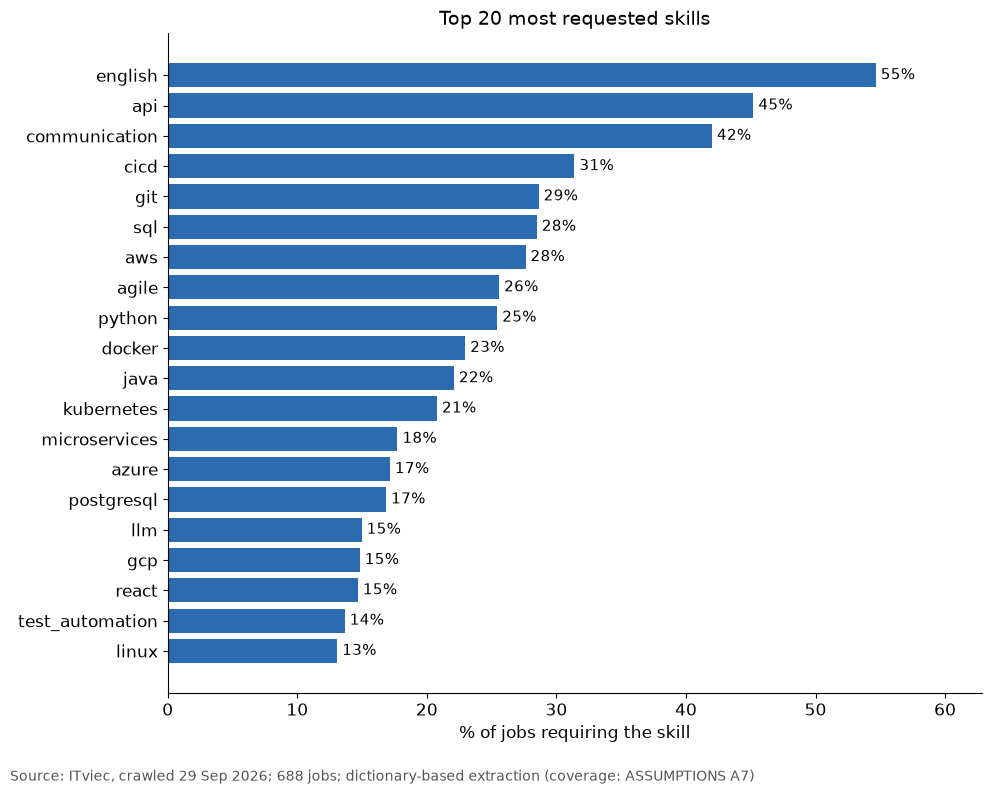

In [3]:
fig = FIGURES["top_skills"](jobs, skills)

## 3. Locations

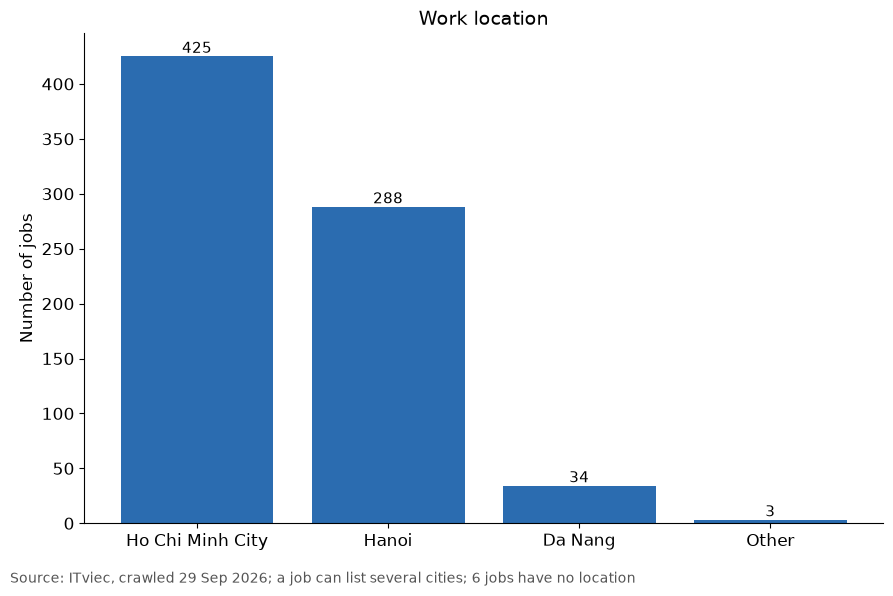

In [4]:
fig = FIGURES["locations"](jobs, skills)

## 4. Seniority

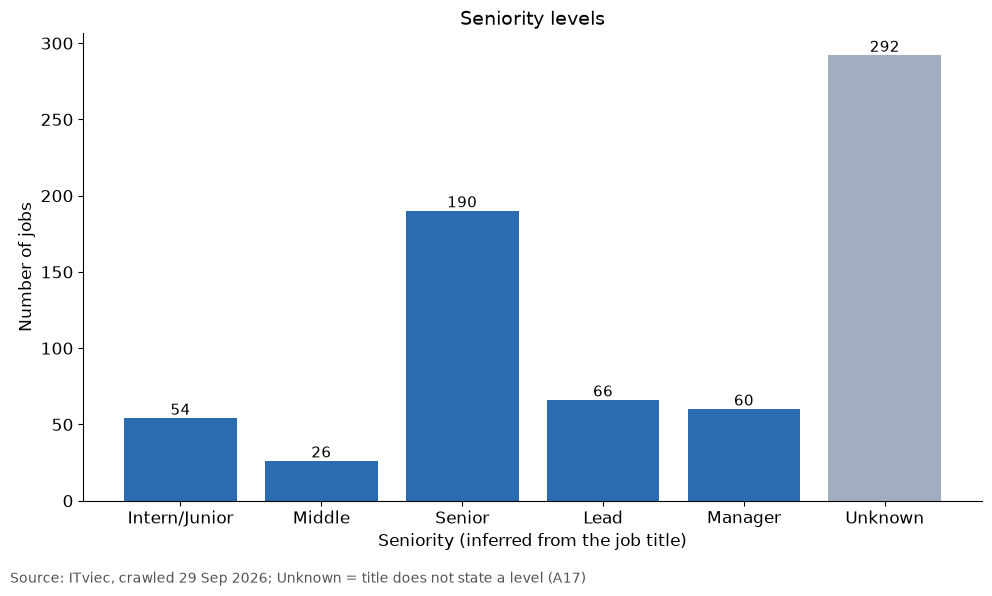

In [5]:
fig = FIGURES["levels"](jobs, skills)

## 5. Posting timeline

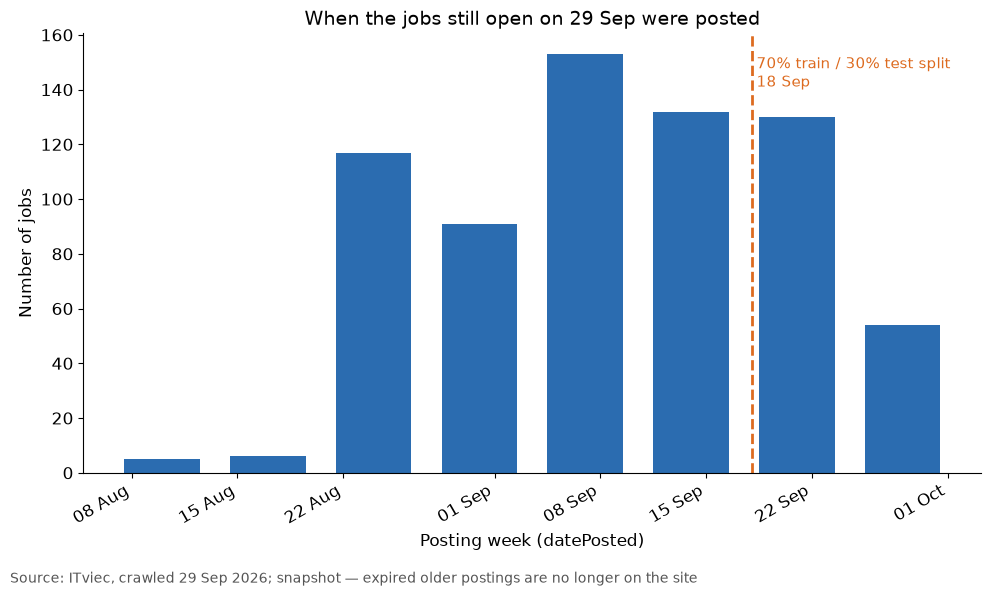

In [6]:
fig = FIGURES["timeline"](jobs, skills)